# 01 — Aquisição, pré-processamento e **segmentação**

**Projeto:** Inspeção visual automática de frutas — Cenário A (central de distribuição).

**Problema.** Separar frutas **OK (fresh)** de **defeituosas (rotten)** em alta velocidade, substituindo a inspeção humana (cara, lenta, inconsistente e subjetiva).

**Dataset.** *Fruits fresh and rotten for classification* (Kaggle) — maçã, banana e laranja, fundo controlado. Usamos **somente as imagens originais** (descartamos as versões aumentadas por rotação/translação/ruído presentes no dataset, pois são derivadas das mesmas frutas e causariam **vazamento de dados** entre treino e teste).

**Tarefa de classificação:** binária **fresh × rotten**, com as 3 frutas juntas e **balanceadas** (~200 imagens por classe → 67 por fruta×condição).

Este notebook cobre a **aquisição**, o **pré-processamento** e a **segmentação** (isolamento do objeto), comparando **dois métodos**.

In [1]:
import sys, os
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
pd.set_option('display.width', 120); pd.set_option('display.max_columns', 60)
from src import config as cfg, dataset as ds, segmentation as seg
index = ds.build_sample_index()
print('Total de imagens amostradas:', len(index))
display(index.groupby(['fruit','label_name']).size().unstack())

Total de imagens amostradas: 402


label_name,fresh,rotten
fruit,,
apple,67,67
banana,67,67
orange,67,67


## Exemplos por classe
Frutas isoladas sobre fundo claro. Note os sinais visuais de podridão: manchas escuras, escurecimento (marrom), rugas e textura irregular.

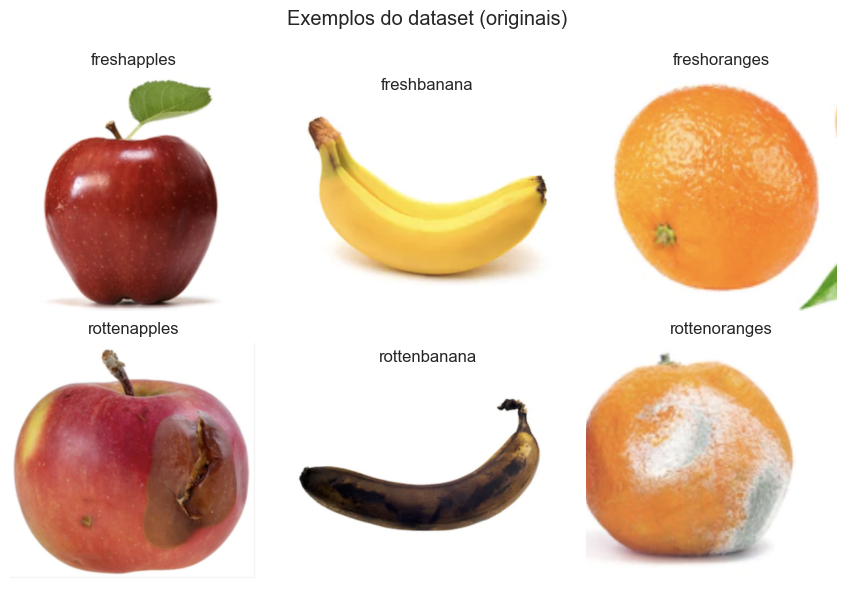

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(9, 6))
for ax, folder in zip(axes.ravel(), cfg.FOLDER_INFO):
    r = index[index.folder==folder].iloc[0]
    ax.imshow(ds.load_image(r['path'])); ax.set_title(folder); ax.axis('off')
fig.suptitle('Exemplos do dataset (originais)'); fig.tight_layout()
fig.savefig(cfg.FIG_DIR/'exemplos_dataset.png', dpi=130); plt.show()

## Dois métodos de segmentação

**Método A — Otsu (tons de cinza).** Limiar global automático sobre a imagem em tons de cinza; o fundo claro é separado do objeto mais escuro.

**Método B — Cor em HSV (remoção de fundo).** O fundo (branco nas originais, preto nas aumentadas) tem **baixa saturação** e valor (V) muito alto **ou** muito baixo; a fruta é colorida. Definimos objeto = *não fundo*.

Ambos passam por limpeza morfológica, **preenchimento de buracos** e seleção do **maior componente conectado**.

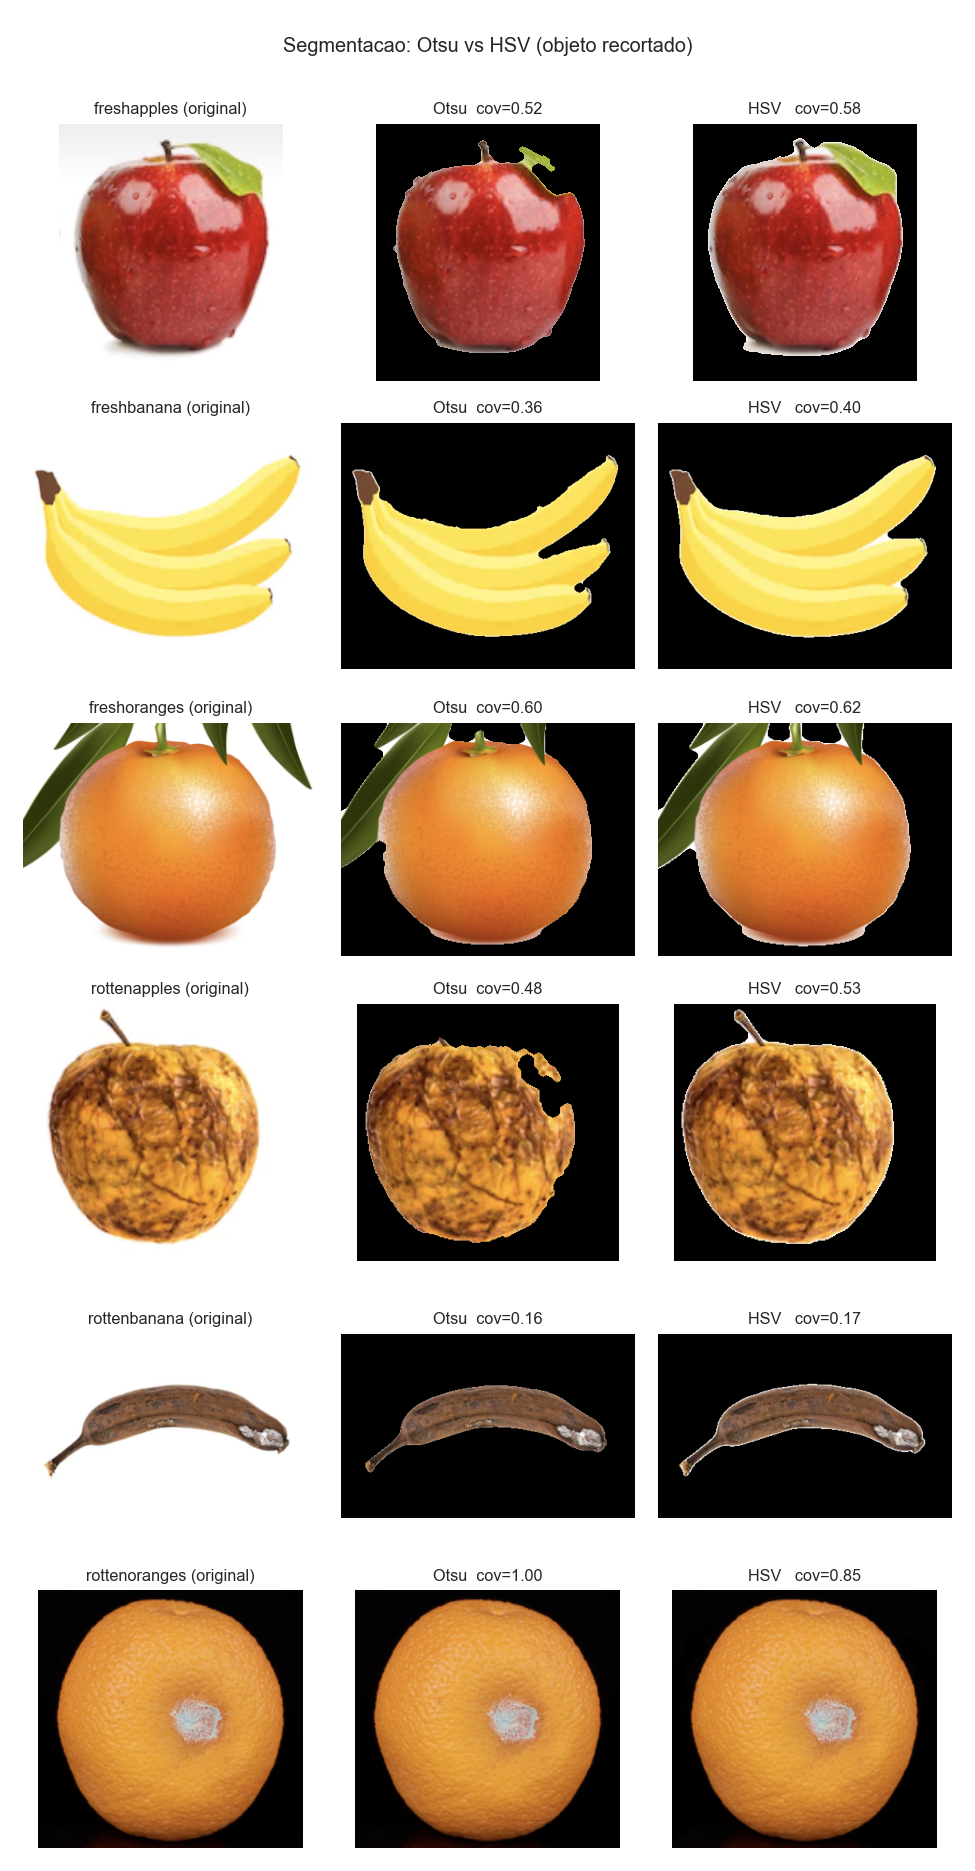

In [3]:
from src import viz_segmentation as vz
out = vz.comparison_grid(index)
from IPython.display import Image; Image(str(out))

## Comparação quantitativa: cobertura da máscara
A **cobertura** é a fração da imagem ocupada pela máscara. Comparamos a estabilidade dos dois métodos em toda a amostra.

In [4]:
import numpy as np
rows=[]
for _,r in index.iterrows():
    img = ds.load_image(r['path'])
    rows.append({'otsu': seg.mask_coverage(seg.segment_otsu(img)),
                 'hsv':  seg.mask_coverage(seg.segment_hsv(img)),
                 'folder': r['folder']})
cov = pd.DataFrame(rows)
print('Cobertura média / desvio por método:')
display(cov[['otsu','hsv']].agg(['mean','std','min','max']).round(3))
# falhas grosseiras: mascara ~vazia ou ~imagem inteira
for m in ['otsu','hsv']:
    falhas = ((cov[m]<0.10)|(cov[m]>0.99)).sum()
    print(f'{m}: {falhas} casos extremos (cov<0.10 ou >0.99)')

Cobertura média / desvio por método:


,otsu,hsv
mean,0.453,0.620
std,0.165,0.204
min,0.043,0.162
max,1.000,1.000


otsu: 12 casos extremos (cov<0.10 ou >0.99)
hsv: 45 casos extremos (cov<0.10 ou >0.99)


In [5]:
fig,ax=plt.subplots(figsize=(6,3.5))
sns.kdeplot(cov['otsu'],label='Otsu',fill=True,ax=ax)
sns.kdeplot(cov['hsv'],label='HSV',fill=True,ax=ax)
ax.set_title('Distribuição da cobertura da máscara'); ax.set_xlabel('cobertura'); ax.legend()
fig.tight_layout(); fig.savefig(cfg.SEG_DIR/'cobertura_otsu_vs_hsv.png',dpi=130); plt.show()

## Discussão e escolha

- **Otsu** falha quando a fruta é clara e próxima do fundo (ex.: **laranjas frescas**), chegando a segmentar a imagem inteira ou quase nada — o limiar único de cinza não separa bem objetos claros sobre fundo claro.
- **HSV** é mais robusto porque usa a baixa saturação do fundo, lidando tanto com fundo branco quanto com o preto das bordas de imagens rotacionadas.
- Casos de cobertura ~1.0 no HSV correspondem a **recortes justos** (a fruta preenche o quadro), não a falhas.

**Escolhemos o método HSV** para o pipeline principal. Segmentação imperfeita é parte do desafio real e é tratada com o pós-processamento morfológico.